<a href="https://colab.research.google.com/github/Engfatiimah/Minig_Project/blob/main/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Analysis:


This section analyzes the selected dataset using statistical summaries and visualization techniques. The analysis includes statistical summaries, missing values analysis, outlier detection, variable distributions, class label distribution, and different types of plots.

The purpose of this analysis is to understand the characteristics of the dataset and identify issues that may require preprocessing.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
url = "https://raw.githubusercontent.com/Engfatiimah/Minig_Project/main/Dataset/Raw_dataset.csv"
df = pd.read_csv(url)

num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
            'Credit_History', 'Property_Area']
target = 'Loan_Status'

**1. Statistical Summary**


The statistical summary of the numeric attributes shows the count, mean, standard deviation, minimum, Q1, median, Q3, and maximum values of the numeric attributes.
ApplicantIncome, CoapplicantIncome, and LoanAmount have large differences between their minimum and maximum values. Therefore, boxplots are used to further examine their distributions and potential outliers.

In [ ]:
df[num_cols].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
count,614.000000,614.000000,592.000000,600.00000
mean,5403.459283,1621.245798,146.412162,342.00000
std,6109.041673,2926.248369,85.587325,65.12041
min,150.000000,0.000000,9.000000,12.00000
25%,2877.500000,0.000000,100.000000,360.00000
50%,3812.500000,1188.500000,128.000000,360.00000
75%,5795.000000,2297.250000,168.000000,360.00000
max,81000.000000,41667.000000,700.000000,480.00000


**2. Missing Values Analysis**

The dataset was checked to identify missing values in each attribute.

Missing values were found in Gender, Married, Dependents, Self_Employed, LoanAmount, Loan_Amount_Term, and Credit_History.

These missing values indicate that the dataset needs preprocessing.

In [ ]:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_values = pd.DataFrame({'Missing Values': missing_count,'Percentage (%)': missing_percentage.round(2)})

missing_values[missing_values['Missing Values'] > 0]

,Missing Values,Percentage (%)
Gender,13,2.12
Married,3,0.49
Dependents,15,2.44
Self_Employed,32,5.21
LoanAmount,22,3.58
Loan_Amount_Term,14,2.28
Credit_History,50,8.14


**3. Outlier Analysis**

Boxplots were used to examine the distribution of the numeric attributes and identify potential outliers.


The boxplots show potential outliers in ApplicantIncome, CoapplicantIncome, LoanAmount, and Loan_Amount_Term.

These potential outliers indicate that the numeric attributes should be considered during the preprocessing stage.

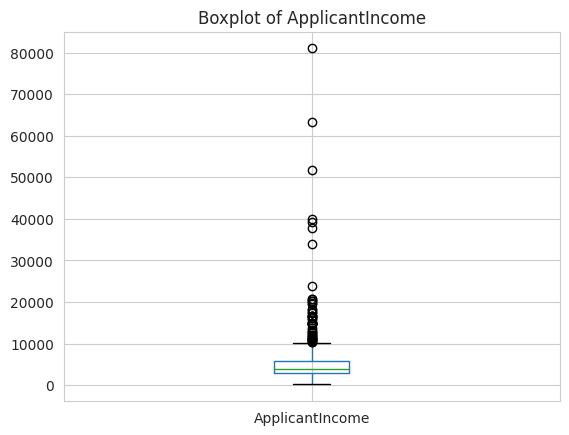

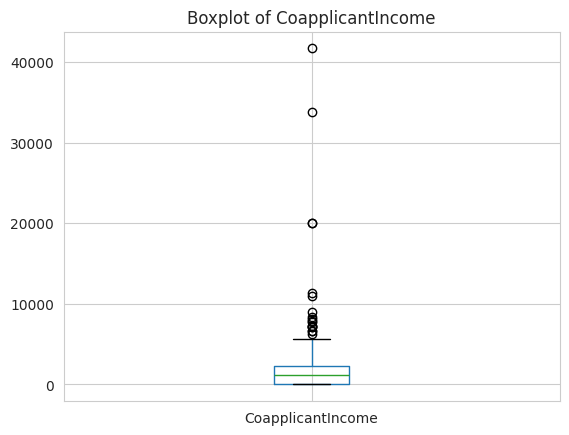

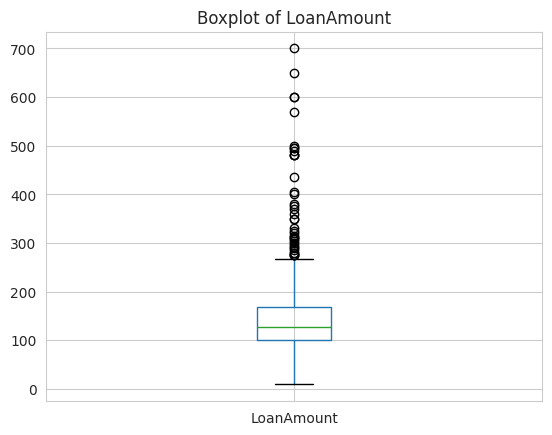

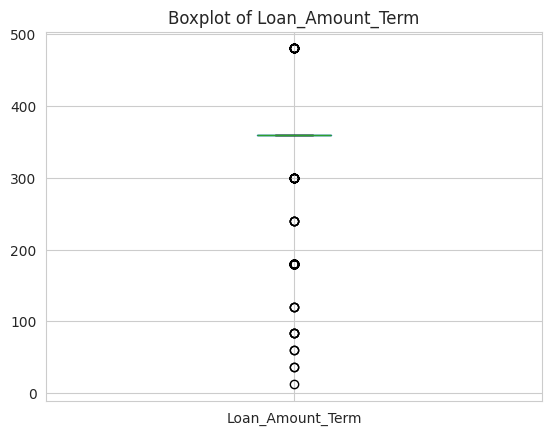

In [ ]:
for col in num_cols:
    df.boxplot(column=col)
    plt.title('Boxplot of ' + col)
    plt.show()

Outlier Detection Using IQR:

The Interquartile Range (IQR) method was used to identify potential outliers in the numeric attributes.

The IQR is calculated as:

IQR = Q3 - Q1

Values below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR are considered potential outliers


The IQR method identified potential outliers in ApplicantIncome, CoapplicantIncome, LoanAmount, and Loan_Amount_Term.

These results support the observations from the boxplots and show that potential outliers should be considered during the preprocessing stage.

In [ ]:
for col in num_cols:
    data = df[col].dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data < lower_bound) | (data > upper_bound)]

    print(col+":")
    print(f"Number of potential outliers: {len(outliers)}")

    print()

ApplicantIncome:
Number of potential outliers: 50

CoapplicantIncome:
Number of potential outliers: 18

LoanAmount:
Number of potential outliers: 39

Loan_Amount_Term:
Number of potential outliers: 88



**4. Histograms**


The histograms show the distribution of the numeric attributes.

ApplicantIncome, CoapplicantIncome, and LoanAmount are **right-skewed**, where most values are small and few values are very large. Most values of Loan_Amount_Term are 360.

The numeric attributes also have different ranges, so they need to be **normalized** during the preprocessing stage.

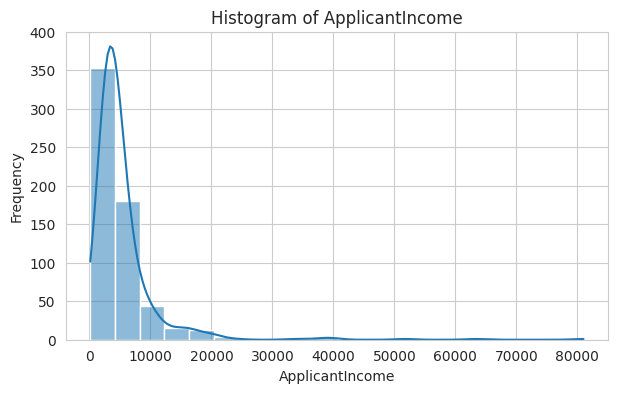

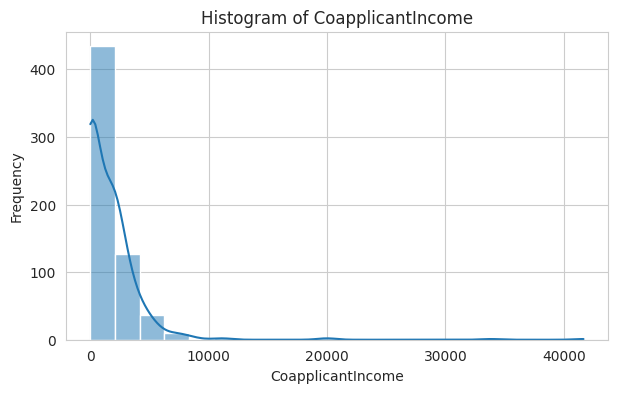

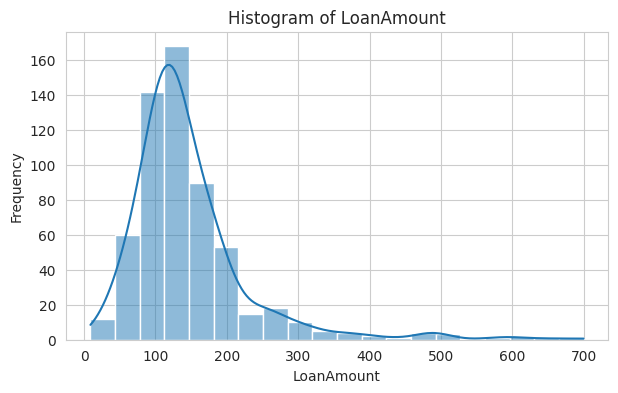

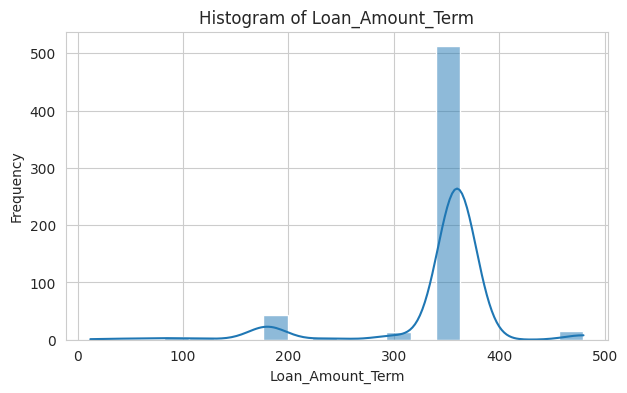

In [ ]:
for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title('Histogram of ' + col)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()



**5. Bar Plots**


The bar plots show the frequency of each value in the categorical attributes.

Some attributes are **imbalanced**, such as Gender (489 Male, 112 Female) and Self_Employed (500 No, 82 Yes). Property_Area is the most balanced attribute.

These attributes contain text values, and Dependents contains the value "3+". Therefore, they will be **encoded** into numeric values before applying the data mining techniques in Phase 3.

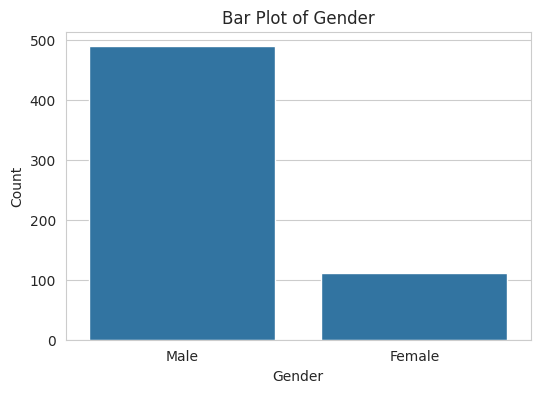

Gender
Male      489
Female    112
Name: count, dtype: int64 



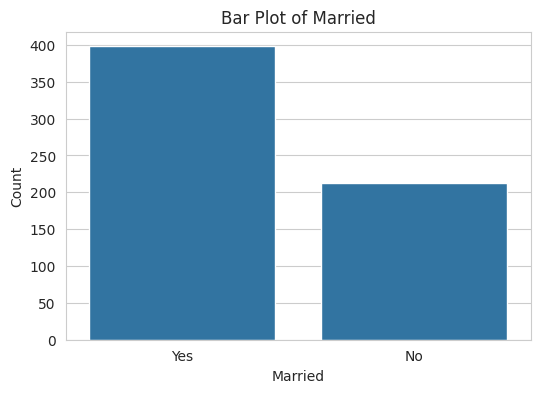

Married
Yes    398
No     213
Name: count, dtype: int64 



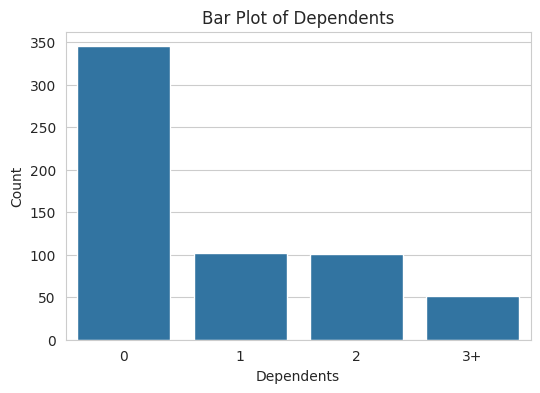

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64 



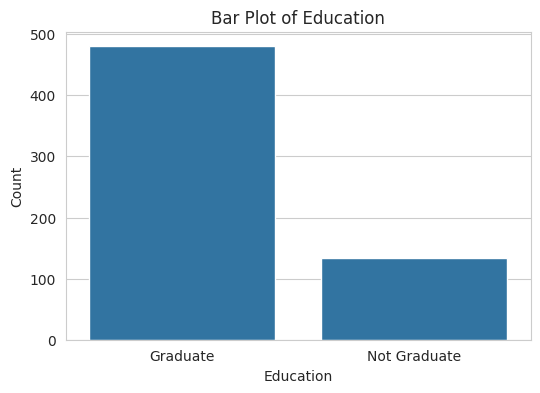

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64 



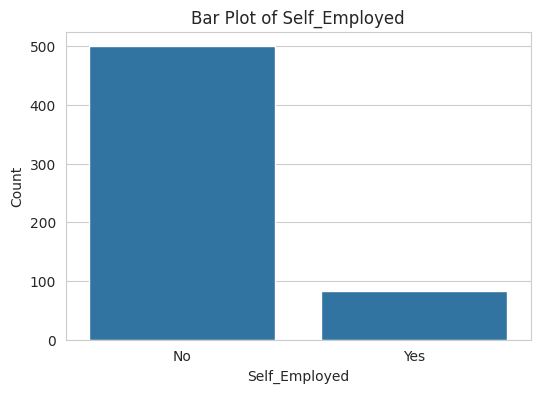

Self_Employed
No     500
Yes     82
Name: count, dtype: int64 



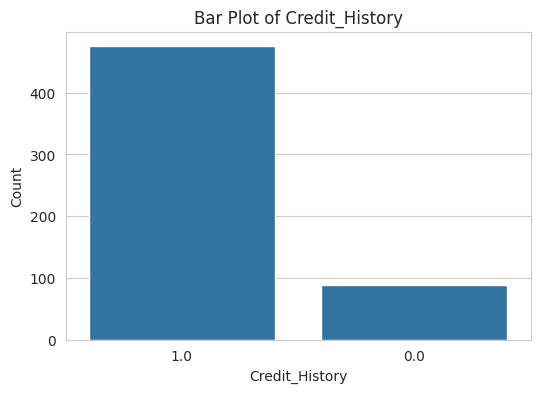

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64 



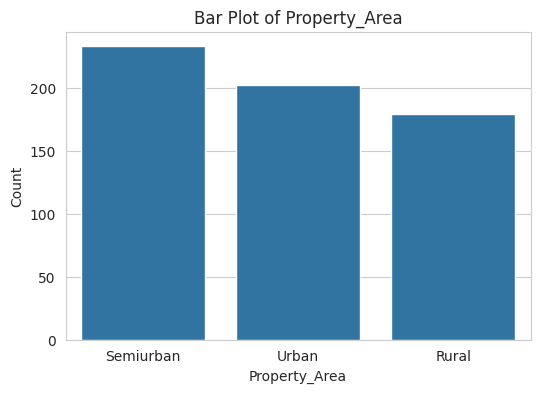

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64 



In [ ]:
for col in cat_cols:
    counts = df[col].value_counts()
    plt.figure(figsize=(6, 4))
    sns.barplot(x=counts.index.astype(str), y=counts.values)
    plt.title('Bar Plot of ' + col)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()
    print(counts, '\n')

**6. Scatter Plots**


The scatter plots show the relationship between LoanAmount and other numeric attributes. The **correlation coefficient (r)** was calculated to measure the strength of each relationship.

ApplicantIncome and LoanAmount have a **positive correlation (r = 0.57)**, which means applicants with higher income usually request larger loans. CoapplicantIncome has a **weak correlation (r = 0.19)**, and Loan_Amount_Term has **almost no correlation (r = 0.04)**.

The plots also show some extreme values that affect the scale, which supports the need for **normalization**.

In [ ]:
def correlation(a, b):
    data = df[[a, b]].dropna()
    A, B = data[a], data[b]
    n = len(data)
    return ((A * B).sum() - n * A.mean() * B.mean()) / (n * A.std(ddof=0) * B.std(ddof=0))

print('ApplicantIncome vs LoanAmount   r =', round(correlation('ApplicantIncome', 'LoanAmount'), 2))
print('CoapplicantIncome vs LoanAmount r =', round(correlation('CoapplicantIncome', 'LoanAmount'), 2))
print('Loan_Amount_Term vs LoanAmount  r =', round(correlation('Loan_Amount_Term', 'LoanAmount'), 2))

ApplicantIncome vs LoanAmount   r = 0.57
CoapplicantIncome vs LoanAmount r = 0.19
Loan_Amount_Term vs LoanAmount  r = 0.04


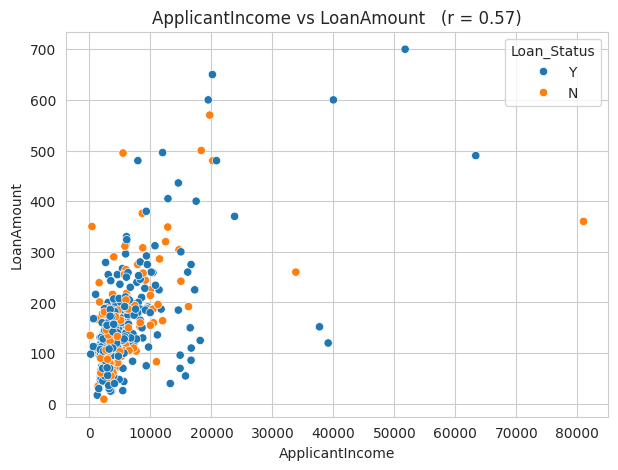

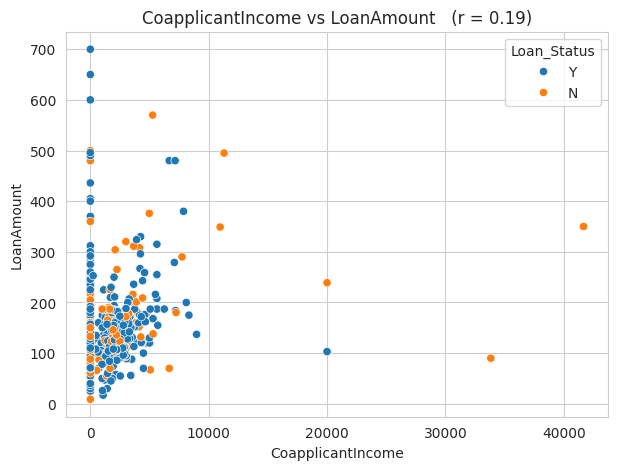

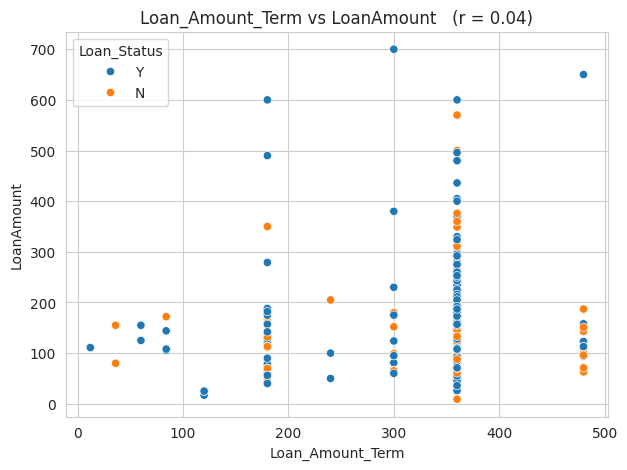

In [ ]:
pairs = [('ApplicantIncome', 'LoanAmount'),
         ('CoapplicantIncome', 'LoanAmount'),
         ('Loan_Amount_Term', 'LoanAmount')]

for x, y in pairs:
    r = correlation(x, y)
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df, x=x, y=y, hue=target)
    plt.title(x + ' vs ' + y + '   (r = ' + str(round(r, 2)) + ')')
    plt.show()

**7. Class Label Distribution**


The class label Loan_Status has two classes: **Y with 422 instances (68.73%)** and **N with 192 instances (31.27%)**.

The dataset is **imbalanced** because the number of approved loans is much higher than the number of rejected loans. This should be considered when evaluating the classification results.

In [ ]:
class_counts = df[target].value_counts()
class_percent = df[target].value_counts(normalize=True) * 100

print('Number of classes:', df[target].nunique())
print()
print('Count of each class:')
print(class_counts)
print()
print('Percentage of each class:')
print(class_percent.round(2))

Number of classes: 2

Count of each class:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Percentage of each class:
Loan_Status
Y    68.73
N    31.27
Name: proportion, dtype: float64


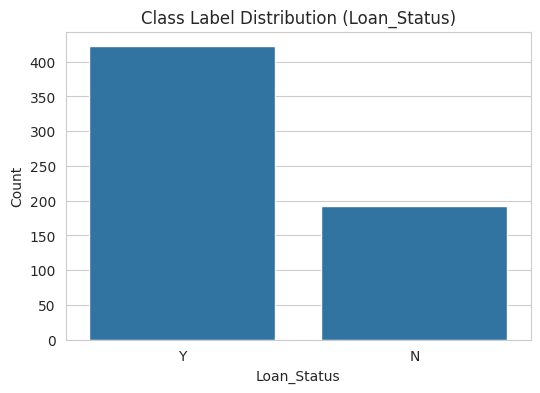

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Label Distribution (Loan_Status)')
plt.xlabel('Loan_Status')
plt.ylabel('Count')
plt.show()

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [ ]:
columns_with_missing = ['Gender', 'Married', 'Dependents',
                        'Self_Employed', 'LoanAmount',
                        'Loan_Amount_Term', 'Credit_History']

for col in columns_with_missing:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

Gender
Gender
Male      489
Female    112
NaN        13
Name: count, dtype: int64

Married
Married
Yes    398
No     213
NaN      3
Name: count, dtype: int64

Dependents
Dependents
0      345
1      102
2      101
3+      51
NaN     15
Name: count, dtype: int64

Self_Employed
Self_Employed
No     500
Yes     82
NaN     32
Name: count, dtype: int64

LoanAmount
LoanAmount
NaN      22
120.0    20
110.0    17
100.0    15
187.0    12
         ..
292.0     1
142.0     1
350.0     1
496.0     1
253.0     1
Name: count, Length: 204, dtype: int64

Loan_Amount_Term
Loan_Amount_Term
360.0    512
180.0     44
480.0     15
NaN       14
300.0     13
84.0       4
240.0      4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

Credit_History
Credit_History
1.0    475
0.0     89
NaN     50
Name: count, dtype: int64



## Data Preprocessing
Based on the data analysis above, preprocessing was applied to address the identified data quality and representation issues. The preprocessing steps include handling missing values, normalization, and discretization.

 **1. Handling Missing Values**

Based on the missing values analysis, several attributes contained missing values that required preprocessing. The mode was used for the categorical and discrete attributes (Gender, Married, Dependents, Self_Employed, Loan_Amount_Term, and Credit_History), while the median was used for the numerical attribute LoanAmount. After applying these methods, all missing values were handled while preserving all records in the dataset.

In [ ]:
# Fill categorical/discrete missing values using the mode
mode_columns = ['Gender', 'Married', 'Dependents',
                'Self_Employed', 'Loan_Amount_Term', 'Credit_History']

for col in mode_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical missing values using the median
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
df.select_dtypes(include='number').columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

**2. Normalization**

Based on the statistical summaries and distributions observed during data analysis, the numerical attributes had different scales. Therefore, Min-Max normalization was applied to ApplicantIncome, CoapplicantIncome, and LoanAmount, transforming their values to the range [0,1]. This places the selected attributes on a common scale while preserving their relative differences.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

columns_to_normalize = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

scaler = MinMaxScaler()
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

df[columns_to_normalize].head()

,ApplicantIncome,CoapplicantIncome,LoanAmount
0,0.070489,0.000000,0.172214
1,0.054830,0.036192,0.172214
2,0.035250,0.000000,0.082489
3,0.030093,0.056592,0.160637
4,0.072356,0.000000,0.191027


**3. Discretization**

Based on the distribution of LoanAmount observed during data analysis, discretization was applied to simplify its continuous numerical values into meaningful categories. Equal-frequency discretization using qcut divided LoanAmount into three categories: Low, Medium, and High. This produced approximately balanced groups and made the attribute easier to interpret and analyze.

In [ ]:
df['LoanAmount_Category'] = pd.qcut(
    df['LoanAmount'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df['LoanAmount_Category'].value_counts()

,count
LoanAmount_Category,
Medium,208
Low,206
High,200


 **4. Comparison: Before and After Preprocessing**

The raw and preprocessed datasets were compared to show the effect of the applied preprocessing techniques. After preprocessing, missing values were handled, selected numerical attributes were normalized to the range [0,1], and LoanAmount was discretized into Low, Medium, and High categories. The preprocessed dataset is more complete, consistent, and suitable for further data mining tasks while preserving all 614 records.

In [ ]:
# Load raw dataset for comparison
raw_df = pd.read_csv(url)

# Display snapshots
print("=== Raw Dataset (Before Preprocessing) ===")
display(raw_df.head(5))

print("\n=== Preprocessed Dataset (After Preprocessing) ===")
display(df.head(5))

# Save preprocessed dataset to CSV
df.to_csv('Preprocessed_dataset.csv', index=False)

# Download CSV file
from google.colab import files
files.download('Preprocessed_dataset.csv')

=== Raw Dataset (Before Preprocessing) ===


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



=== Preprocessed Dataset (After Preprocessing) ===


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_Category
0,LP001002,Male,No,0,Graduate,No,0.070489,0.000000,0.172214,360.0,1.0,Urban,Y,Medium
1,LP001003,Male,Yes,1,Graduate,No,0.054830,0.036192,0.172214,360.0,1.0,Rural,N,Medium
2,LP001005,Male,Yes,0,Graduate,Yes,0.035250,0.000000,0.082489,360.0,1.0,Urban,Y,Low
3,LP001006,Male,Yes,0,Not Graduate,No,0.030093,0.056592,0.160637,360.0,1.0,Urban,Y,Medium
4,LP001008,Male,No,0,Graduate,No,0.072356,0.000000,0.191027,360.0,1.0,Urban,Y,Medium


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>